In [8]:
# ============================================
# Fraud Detection Model Evaluation Notebook
# ============================================

import os
import time
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [9]:
# Load data

train_path = "../data/processed/features/train_features_selected_enhanced.parquet"
test_path  = "../data/processed/features/test_features_selected_enhanced.parquet"

t0 = time.time()
train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)
print("Train:", train_df.shape, "Test:", test_df.shape, "Load time:", round(time.time()-t0, 2), "sec")

X = train_df.drop(columns=["TransactionID", "isFraud"])
y = train_df["isFraud"].astype(int)
test_ids = test_df["TransactionID"]
X_test = test_df.drop(columns=["TransactionID"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train rows:", len(X_train), "Validation rows:", len(X_val))


Train: (590540, 110) Test: (506691, 109) Load time: 0.54 sec
Train rows: 472432 Validation rows: 118108


In [10]:
train_df.sample(10)

,TransactionID,isFraud,V56,M3_encoded,card5,V200,is_mail_comR,V248,V170,V232,...,V249,V247,V70,V258,addr2,is_amount_outlier,missing_email_features,missing_overall,card6_encoded,M6_encoded
470624,3457624,0,1.0,0,224.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,87.0,1,0.5,0.286885,2,1
565820,3552820,0,1.0,1,226.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,87.0,0,0.5,0.278689,2,1
284083,3271083,0,1.0,1,224.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,1.0,-999.0,87.0,0,0.5,0.278689,2,0
239689,3226689,0,2.0,2,138.0,-999.0,1,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,-999.0,0,0.0,0.299180,2,2
281855,3268855,0,1.0,2,226.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,1.0,-999.0,87.0,0,0.5,0.286885,2,1
413908,3400908,0,1.0,1,166.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,87.0,1,0.5,0.286885,2,0
413692,3400692,0,1.0,1,226.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,1.0,-999.0,87.0,1,0.5,0.278689,2,2
474182,3461182,0,1.0,1,226.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,87.0,1,0.5,0.438525,1,1
370788,3357788,1,2.0,2,138.0,2.0,0,1.0,2.0,0.0,...,1.0,1.0,0.0,1.0,-999.0,0,0.0,0.106557,2,2
28757,3015757,0,1.0,0,226.0,-999.0,0,-999.0,-999.0,-999.0,...,-999.0,-999.0,0.0,-999.0,87.0,1,0.5,0.278689,2,0


In [11]:
test_df.head()

,TransactionID,V56,M3_encoded,card5,V200,is_mail_comR,V248,V170,V232,TransactionAmt,...,V249,V247,V70,V258,addr2,is_amount_outlier,missing_email_features,missing_overall,card6_encoded,M6_encoded
0,3663549,1.0,0,226.0,-999.0,0,-999.0,-999.0,-999.0,31.95,...,-999.0,-999.0,0.0,-999.0,87.0,0,0.5,0.278689,2,0
1,3663550,1.0,0,226.0,-999.0,0,-999.0,-999.0,-999.0,49.00,...,-999.0,-999.0,0.0,-999.0,87.0,0,0.5,0.278689,2,0
2,3663551,1.0,0,226.0,-999.0,0,-999.0,-999.0,-999.0,171.00,...,-999.0,-999.0,0.0,-999.0,87.0,0,0.5,0.278689,2,0
3,3663552,1.0,1,166.0,-999.0,0,-999.0,-999.0,-999.0,284.95,...,-999.0,-999.0,1.0,-999.0,87.0,1,0.5,0.278689,2,1
4,3663553,1.0,1,117.0,-999.0,0,-999.0,-999.0,-999.0,67.95,...,-999.0,-999.0,1.0,-999.0,87.0,0,0.5,0.278689,2,0


In [4]:
# Identify Feature Types

def detect_features(df):
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    bin_cols = [c for c in nums if df[c].nunique() == 2]
    cont_cols = [c for c in nums if c not in bin_cols]
    return cont_cols, bin_cols

cont_cols, bin_cols = detect_features(X_train)

pre_basic = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cont_cols),
        ("binary", "passthrough", bin_cols)
    ],
    remainder="passthrough"
)

pre_pass = ColumnTransformer(transformers=[], remainder="passthrough")

In [5]:
# Fixed Stratified Subsampling
def stratified_subsample(Xd, yd, n, seed=42):
    """Stratified subsample to ensure both classes appear."""
    total = len(Xd)
    if n >= total:
        return Xd.copy(), yd.copy()

    sss = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=seed)
    idx, _ = next(sss.split(Xd, yd))
    return Xd.iloc[idx], yd.iloc[idx]


# Precomputed stratified subsets
X_svc, y_svc = stratified_subsample(X_train, y_train, 10000)
X_l1_sample, y_l1_sample = stratified_subsample(X_train, y_train, 50000)

In [6]:
# Model Dictionary

# ---------------------------
# Simplified Senior-Level Model Dictionary
# ---------------------------

model_dict = {
    "log_reg": {
        "estimator": LogisticRegression(
            solver="saga", penalty="l2", C=0.1, class_weight="balanced",
            max_iter=500, n_jobs=-1, random_state=42
        ),
        "phaseA": {},
        "phaseB": {}
    },

    "random_forest": {
        "estimator": RandomForestClassifier(
            n_estimators=100, max_depth=12, min_samples_split=100,
            class_weight="balanced", n_jobs=-1, random_state=42
        ),
        "phaseA": {"n_estimators": 100},
        "phaseB": {"n_estimators": 300}
    },

    "xgboost": {
        "estimator": XGBClassifier(
            n_estimators=100, eval_metric="auc",
            scale_pos_weight=10,    # adjust by class imbalance ratio
            random_state=42, n_jobs=-1
        ),
        "phaseA": {"n_estimators": 100},
        "phaseB": {"n_estimators": 300}
    },

    "lightgbm": {
        "estimator": LGBMClassifier(
            n_estimators=100, is_unbalance=True, metric="auc",
            n_jobs=-1, random_state=42
        ),
        "phaseA": {"n_estimators": 100},
        "phaseB": {"n_estimators": 300}
    }
}


In [7]:
# Scoring function

def evaluate_model(name, entry, pre, Xd, yd, Xv, yv, phase):
    model = clone(entry["estimator"])

    if phase == "A":
        params = entry["phaseA"]
    else:
        params = entry["phaseB"]

    for k, v in params.items():
        if hasattr(model, k):
            setattr(model, k, v)

    if phase == "A":
        if name == "svc" and "subset" in entry["phaseA"]:
            X_use, y_use = X_svc, y_svc
        elif name == "lasso" and "subset" in entry["phaseA"]:
            X_use, y_use = X_l1_sample, y_l1_sample
        else:
            X_use, y_use = Xd, yd
    else:
        X_use, y_use = Xd, yd

    pipe = Pipeline([("pre", pre), ("model", model)])
    cv = 3 if phase == "A" else 5
    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    auc_scores = cross_val_score(pipe, X_use, y_use, cv=kf, scoring="roc_auc", n_jobs=-1)
    ap_scores  = cross_val_score(pipe, X_use, y_use, cv=kf, scoring="average_precision", n_jobs=-1)

    pipe.fit(X_use, y_use)
    val_p = pipe.predict_proba(Xv)[:, 1]
    val_auc = roc_auc_score(yv, val_p)
    val_ap  = average_precision_score(yv, val_p)

    return [name, auc_scores.mean(), auc_scores.std(),
            ap_scores.mean(), ap_scores.std(), val_auc, val_ap], pipe

In [8]:
# Two-phase evaluation

def run_two_phase(model_dict):
    resultsA = []
    pipesA = {}

    print("Phase A: Screening...")
    for name, entry in model_dict.items():
        pre = pre_pass if name in {"decision_tree","random_forest","extra_trees","gb","xgboost","lightgbm"} else pre_basic
        out, pipe = evaluate_model(name, entry, pre, X_train, y_train, X_val, y_val, "A")
        resultsA.append(out)
        pipesA[name] = pipe
        print(name, round(out[1], 4))

    dfA = pd.DataFrame(resultsA, columns=["name","cv_auc","cv_std","cv_ap","cv_ap_std","val_auc","val_ap"])
    dfA = dfA.sort_values("cv_auc", ascending=False)
    top = dfA.head(5)["name"].tolist()

    resultsB = []
    pipesB = {}

    print("\nPhase B: Final evaluation...")
    for name in top:
        entry = model_dict[name]
        pre = pre_pass if name in {"decision_tree","random_forest","extra_trees","gb","xgboost","lightgbm"} else pre_basic
        out, pipe = evaluate_model(name, entry, pre, X_train, y_train, X_val, y_val, "B")
        resultsB.append(out)
        pipesB[name] = pipe
        print(name, round(out[1], 4))

    dfB = pd.DataFrame(resultsB, columns=["name","cv_auc","cv_std","cv_ap","cv_ap_std","val_auc","val_ap"])
    dfB = dfB.sort_values("val_auc", ascending=False)

    return dfA, dfB, pipesA, pipesB   


phaseA_df, phaseB_df, pipesA, pipesB = run_two_phase(model_dict)

print("\nPhase A:")
display(phaseA_df.round(4))
print("\nPhase B:")
display(phaseB_df.round(4)) 



Phase A: Screening...
log_reg 0.8458
random_forest 0.9143
xgboost 0.9442
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8743
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
lightgbm 0.928

Phase B: Final evaluation...
xgboost 0.9586
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB

,name,cv_auc,cv_std,cv_ap,cv_ap_std,val_auc,val_ap
2,xgboost,0.9442,0.0011,0.6926,0.0044,0.9507,0.7135
3,lightgbm,0.9280,0.0011,0.5963,0.0040,0.9319,0.6029
1,random_forest,0.9143,0.0009,0.5820,0.0013,0.9185,0.5949
0,log_reg,0.8458,0.0019,0.3521,0.0037,0.8507,0.3560



Phase B:


,name,cv_auc,cv_std,cv_ap,cv_ap_std,val_auc,val_ap
0,xgboost,0.9586,0.0015,0.7804,0.0082,0.9648,0.7997
1,lightgbm,0.9472,0.0013,0.6819,0.0060,0.9504,0.6893
2,random_forest,0.9163,0.0028,0.5892,0.0042,0.9187,0.5980
3,log_reg,0.8465,0.0038,0.3531,0.0054,0.8507,0.3560


Best model: xgboost

Running hyperparameter tuning for xgboost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__min_child_weight': 5, 'model__n_estimators': 300}
Best CV score: 0.9576

Final Validation AUC: 0.9915687658230687
Final Validation AP: 0.9083482358393133

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    113975
           1       0.73      0.89      0.80      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.94      0.90    118108
weighted avg       0.99      0.98      0.99    118108



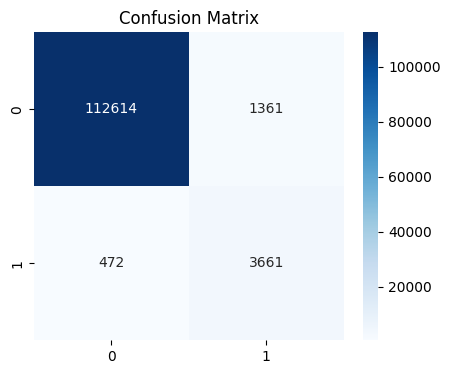

In [10]:
best_model = phaseB_df.iloc[0]["name"]
print("Best model:", best_model)

# HYPERPARAMETER TUNING - ACTUALLY EXECUTE IT
if best_model in ["lightgbm", "xgboost", "random_forest"]:
    print(f"\nRunning hyperparameter tuning for {best_model}...")
    
    preproc_for_tuning = pre_pass if best_model in ["random_forest", "xgboost", "lightgbm"] else pre_basic
    
    # Define parameter grids
    param_grid = {}
    if best_model == "lightgbm":
        param_grid = {
            'model__n_estimators': [200, 300],
            'model__num_leaves': [31, 63],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_samples': [20, 50]
        }
    elif best_model == "xgboost":
        param_grid = {
            'model__n_estimators': [200, 300],
            'model__max_depth': [6, 8],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_weight': [1, 5]
        }
    elif best_model == "random_forest":
        param_grid = {
            'model__n_estimators': [200, 300],
            'model__max_depth': [12, 15],
            'model__min_samples_leaf': [10, 20]
        }
    
    # Clone the best pipeline and run grid search
    base_pipe = clone(pipesB[best_model])
    grid_search = GridSearchCV(
        base_pipe, param_grid, cv=3, scoring='roc_auc', 
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    
    # Use the tuned model
    final_pipe = grid_search.best_estimator_
else:
    # Use the untuned model
    final_pipe = pipesB[best_model]

final_pipe.fit(X, y)

# Validation performance
val_prob = final_pipe.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_prob)
val_ap = average_precision_score(y_val, val_prob)

print("\nFinal Validation AUC:", val_auc)
print("Final Validation AP:", val_ap)

y_pred = (val_prob > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Predictions for Test Set

# Get probability
test_prob = final_pipe.predict_proba(X_test)[:, 1]

# Convert to binary 0/1
test_pred = (test_prob > 0.5).astype(int)

submission = pd.DataFrame({
    "TransactionID": test_ids,
    "isFraud": test_pred       # <-- now 0 or 1
})

out_csv = "../data/processed/features/model_selection_predictions.csv"
submission.to_csv(out_csv, index=False)

model_dir = "../models/"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(final_pipe, os.path.join(model_dir, f"best_pipeline_{best_model}.pkl"))

joblib.dump(
    {
        "features": X.columns.tolist(),
        "continuous": cont_cols,
        "binary": bin_cols,
        "best_model": best_model,
        "val_auc": val_auc,
        "val_ap": val_ap
    },
    os.path.join(model_dir, "preprocessing_info.pkl")
)

print("Saved final model and predictions.")

NameError: name 'final_pipe' is not defined

In [15]:
import pandas as pd
import joblib
import os

# Load the trained pipeline
final_pipe = joblib.load("../models/best_pipeline_xgboost.pkl")

# Load preprocessing info (to get the feature list)
meta = joblib.load("../models/preprocessing_info.pkl")
features = meta['features']  # features used in training

# Load the test data (without isFraud column)

# Keep only the features used for training
X_test = test_df[features]

# Save Transaction IDs for output
test_ids = test_df["TransactionID"]

# Predict probability of fraud
test_prob = final_pipe.predict_proba(X_test)[:, 1]

# Convert probability to binary 0/1 (threshold 0.5)
test_pred = (test_prob > 0.5).astype(int)

# Create submission DataFrame
submission = pd.DataFrame({
    "TransactionID": test_ids,
    "isFraud": test_pred,
    "fraud_probability": test_prob  # optional, if you want probability
})

# Save to CSV
out_csv = "../data/processed/features/model_selection_predictions.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
submission.to_csv(out_csv, index=False)

print("Predictions on test data saved successfully!")


Predictions on test data saved successfully!


In [17]:
print(submission.sample(20).to_string())

        TransactionID  isFraud  fraud_probability
485996        4149545        0           0.031854
458757        4122306        0           0.043073
432972        4096521        0           0.091316
387234        4050783        0           0.014993
349342        4012891        0           0.032578
446404        4109953        0           0.010095
345103        4008652        0           0.369547
100199        3763748        0           0.006169
254422        3917971        0           0.002294
300112        3963661        0           0.001600
7377          3670926        0           0.006170
351762        4015311        0           0.059126
399950        4063499        0           0.030139
438261        4101810        0           0.153223
50600         3714149        0           0.005941
344268        4007817        0           0.003801
414504        4078053        0           0.016779
369501        4033050        1           0.992783
216289        3879838        0           0.000574


In [18]:
# Count of predicted fraud and not-fraud
fraud_counts = submission['isFraud'].value_counts()
print(fraud_counts)

# Calculate fraud rate (% of transactions predicted as fraud)
fraud_rate = (fraud_counts.get(1, 0) / len(submission)) * 100
print(f"Fraud rate: {fraud_rate:.2f}%")

isFraud
0    489375
1     17316
Name: count, dtype: int64
Fraud rate: 3.42%


In [13]:
import joblib
meta = joblib.load("../models/preprocessing_info.pkl")
print(meta.keys())

dict_keys(['features', 'continuous', 'binary', 'best_model', 'val_auc', 'val_ap'])


In [15]:
from sklearn.metrics import roc_auc_score
# Assuming you have y_val and val_pred_proba
kaggle_auc = roc_auc_score(y_val, val_prob)
print(f"Proxy Kaggle Score (AUC): {kaggle_auc:.6f}")

Proxy Kaggle Score (AUC): 0.991569


In [7]:
import pandas as pd
import joblib

# Load model + metadata
best_model_pipe = joblib.load("../models/best_pipeline_xgboost.pkl")
meta = joblib.load("../models/preprocessing_info.pkl")
features = meta['features']

# Load your sample CSV
df = pd.read_csv("../data/sample_data/sample_data.csv")

# Separate features and true labels
X = df[features]
y_true = df["isFraud"]   # actual fraud labels

# Predict probability and class
y_prob = best_model_pipe.predict_proba(X)[:, 1]
y_pred = (y_prob > 0.5).astype(int)   # threshold 0.5

# Create comparison table
results = pd.DataFrame({
    "TransactionID": df["TransactionID"],
    "Actual_isFraud": y_true,
    "Predicted_isFraud": y_pred,
    "Fraud_Probability": y_prob
})

print(results.to_string())

# Optional: accuracy on your sample
accuracy = (results["Actual_isFraud"] == results["Predicted_isFraud"]).mean()
print("\nAccuracy on sample:", accuracy)


    TransactionID  Actual_isFraud  Predicted_isFraud  Fraud_Probability
0         3063557               1                  1           0.992861
1         3152820               1                  1           0.996888
2         3290481               1                  1           0.999063
3         3560146               1                  1           0.998720
4         3295828               1                  1           0.977857
5         3109829               1                  1           0.830649
6         3045400               1                  1           0.988474
7         3575109               1                  1           0.622215
8         3502635               1                  1           0.996639
9         3068443               1                  1           0.914495
10        3072285               0                  0           0.025984
11        3403524               0                  0           0.051891
12        3216133               0                  0           0